# Notebook 4 — Longitudinal and Prognostic Analyses

This notebook examines how predicted brain age evolves over time in the OFAMS
cohort, and whether baseline brain age carries prognostic value for long-term
disability progression.

## Contents

**4.1 Setup**
Imports, plot style, and model color conventions. Master dataframes produced
by Notebook 1 are loaded and a continuous time variable (years since baseline)
is added to each dataframe.

**4.2 Longitudinal BAG trajectories**
Individual subject trajectories and group mean BAG plotted across all
available timepoints, providing a visual overview of longitudinal brain
age dynamics in the cohort.

**4.3 Linear mixed-effects model: change in predicted brain age over time**
LME model (predicted_age ~ age + sex + years_since_baseline + disease_duration)
fitted for each model with a random intercept per subject. The slope of
years_since_baseline reflects the annual rate of change in predicted brain
age, independent of age, sex, and disease duration.

**4.4 Prognostic value of baseline BAG**
Two complementary analyses assess whether baseline BAG predicts long-term
disability progression:

- *BAG as a predictor of EDSS progression* — OLS regression with delta EDSS
  (primary) and future EDSS controlling for baseline (secondary) as outcomes
  at 10-year follow-up. Directly tests whether higher baseline BAG is
  associated with greater disability progression.

- *Incremental model fit* — nested model comparison (LRT and delta R²)
  quantifying the unique variance in future EDSS explained by baseline BAG
  over and above standard clinical predictors, assessed at both 2-year
  and 10-year follow-up.

## 4.1 Setup

In [33]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy.stats as stats
from scipy.stats import pearsonr, spearmanr, ttest_rel
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import warnings



# Suppress non-critical warnings for cleaner notebook output
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# Consistent model colors across all figures
COLORS = {
    'pyment':    '#7B4FA6',
    'brainageR': '#3A8A4A',
    'HBA':       '#D94F4F'
}

### Load data

In [9]:
# Load master dataframes produced by Notebook 1
pyment = pd.read_csv("clean_pyment.csv")
bar    = pd.read_csv("clean_brainageR.csv")
hba    = pd.read_csv("clean_hba.csv")

In [10]:
hba.head(5)

,subject,session,sex,predicted_age,corrected_brainage,age,BAG,protocol,field_strength,manufacturer,edss_score,fatigue,DISEASE_DURATION,SYMPTOM_DURATION,AGE_SYMPTOM_ONSET,AGE_DIAGNOSIS
0,101,m6,F,24.061096,22.933075,35.498289,-11.437193,1,1.5T,Siemens,2.0,6.777778,0,2,32,34
1,101,m24,F,31.079489,30.077149,36.979466,-5.899978,1,1.5T,Siemens,2.0,6.444444,0,2,32,34
2,101,m120,F,40.387276,40.235204,47.000000,-6.612724,1,1.5T,Siemens,2.0,NaN,0,2,32,34
3,103,m6,M,24.829563,22.768398,24.501027,0.328537,1,1.5T,Siemens,1.0,2.888889,1,2,22,23
4,103,m120,M,40.342963,39.257513,36.000000,4.342963,1,1.5T,Siemens,1.0,NaN,1,2,22,23


In [11]:
# Mapping from session labels to time in years since baseline
SESSION_YEARS = {
    'baseline': 0,
    'm1':  0.08,
    'm2':  0.17,
    'm3':  0.25,
    'm4':  0.33,
    'm6':  0.5,
    'm12': 1.0,
    'm24': 2.0,
    'm120': 12.0
}


def prep_longitudinal(df, name):
    """
    Add a continuous time variable (years since baseline) to a longitudinal dataframe.

    Parameters
    ----------
    df : DataFrame
        Full longitudinal dataframe for one model.
    name : str
        Model name used for printed summary.

    Returns
    -------
    DataFrame
        Input dataframe with an added 'years_since_baseline' column.
    """
    df = df.copy()

    # Map session labels to continuous time in years
    df['years_since_baseline'] = df['session'].map(SESSION_YEARS)

    # Print observation counts per session as a sanity check
    counts = (df['session'].value_counts()
                           .reindex(SESSION_YEARS.keys())
                           .dropna())
    print(f"\n{name} — observations per session:")
    print(counts.to_string())

    return df


pyment = prep_longitudinal(pyment, 'pyment')
bar    = prep_longitudinal(bar,    'brainageR')
hba    = prep_longitudinal(hba,    'HBA')


pyment — observations per session:
session
baseline    83
m1          84
m2          85
m3          80
m4          77
m6          86
m12         84
m24         78
m120        75

brainageR — observations per session:
session
baseline    83
m1          84
m2          85
m3          81
m4          77
m6          86
m12         84
m24         78
m120        71

HBA — observations per session:
session
baseline    69
m1           8
m2           5
m3           3
m4           1
m6          70
m12          3
m24         66
m120        69


## 4.2 Longitudinal BAG Trajectories

Before formal modelling, individual and group-level BAG trajectories are
visualized across all available timepoints. Each subject's trajectory is
plotted as a grey line, with the group mean overlaid in the model-specific
color. This provides an initial impression of the direction and variability
of brain age change over the 12-year follow-up, and helps identify whether
any systematic trend is visible at the group level before accounting for
covwith caution.

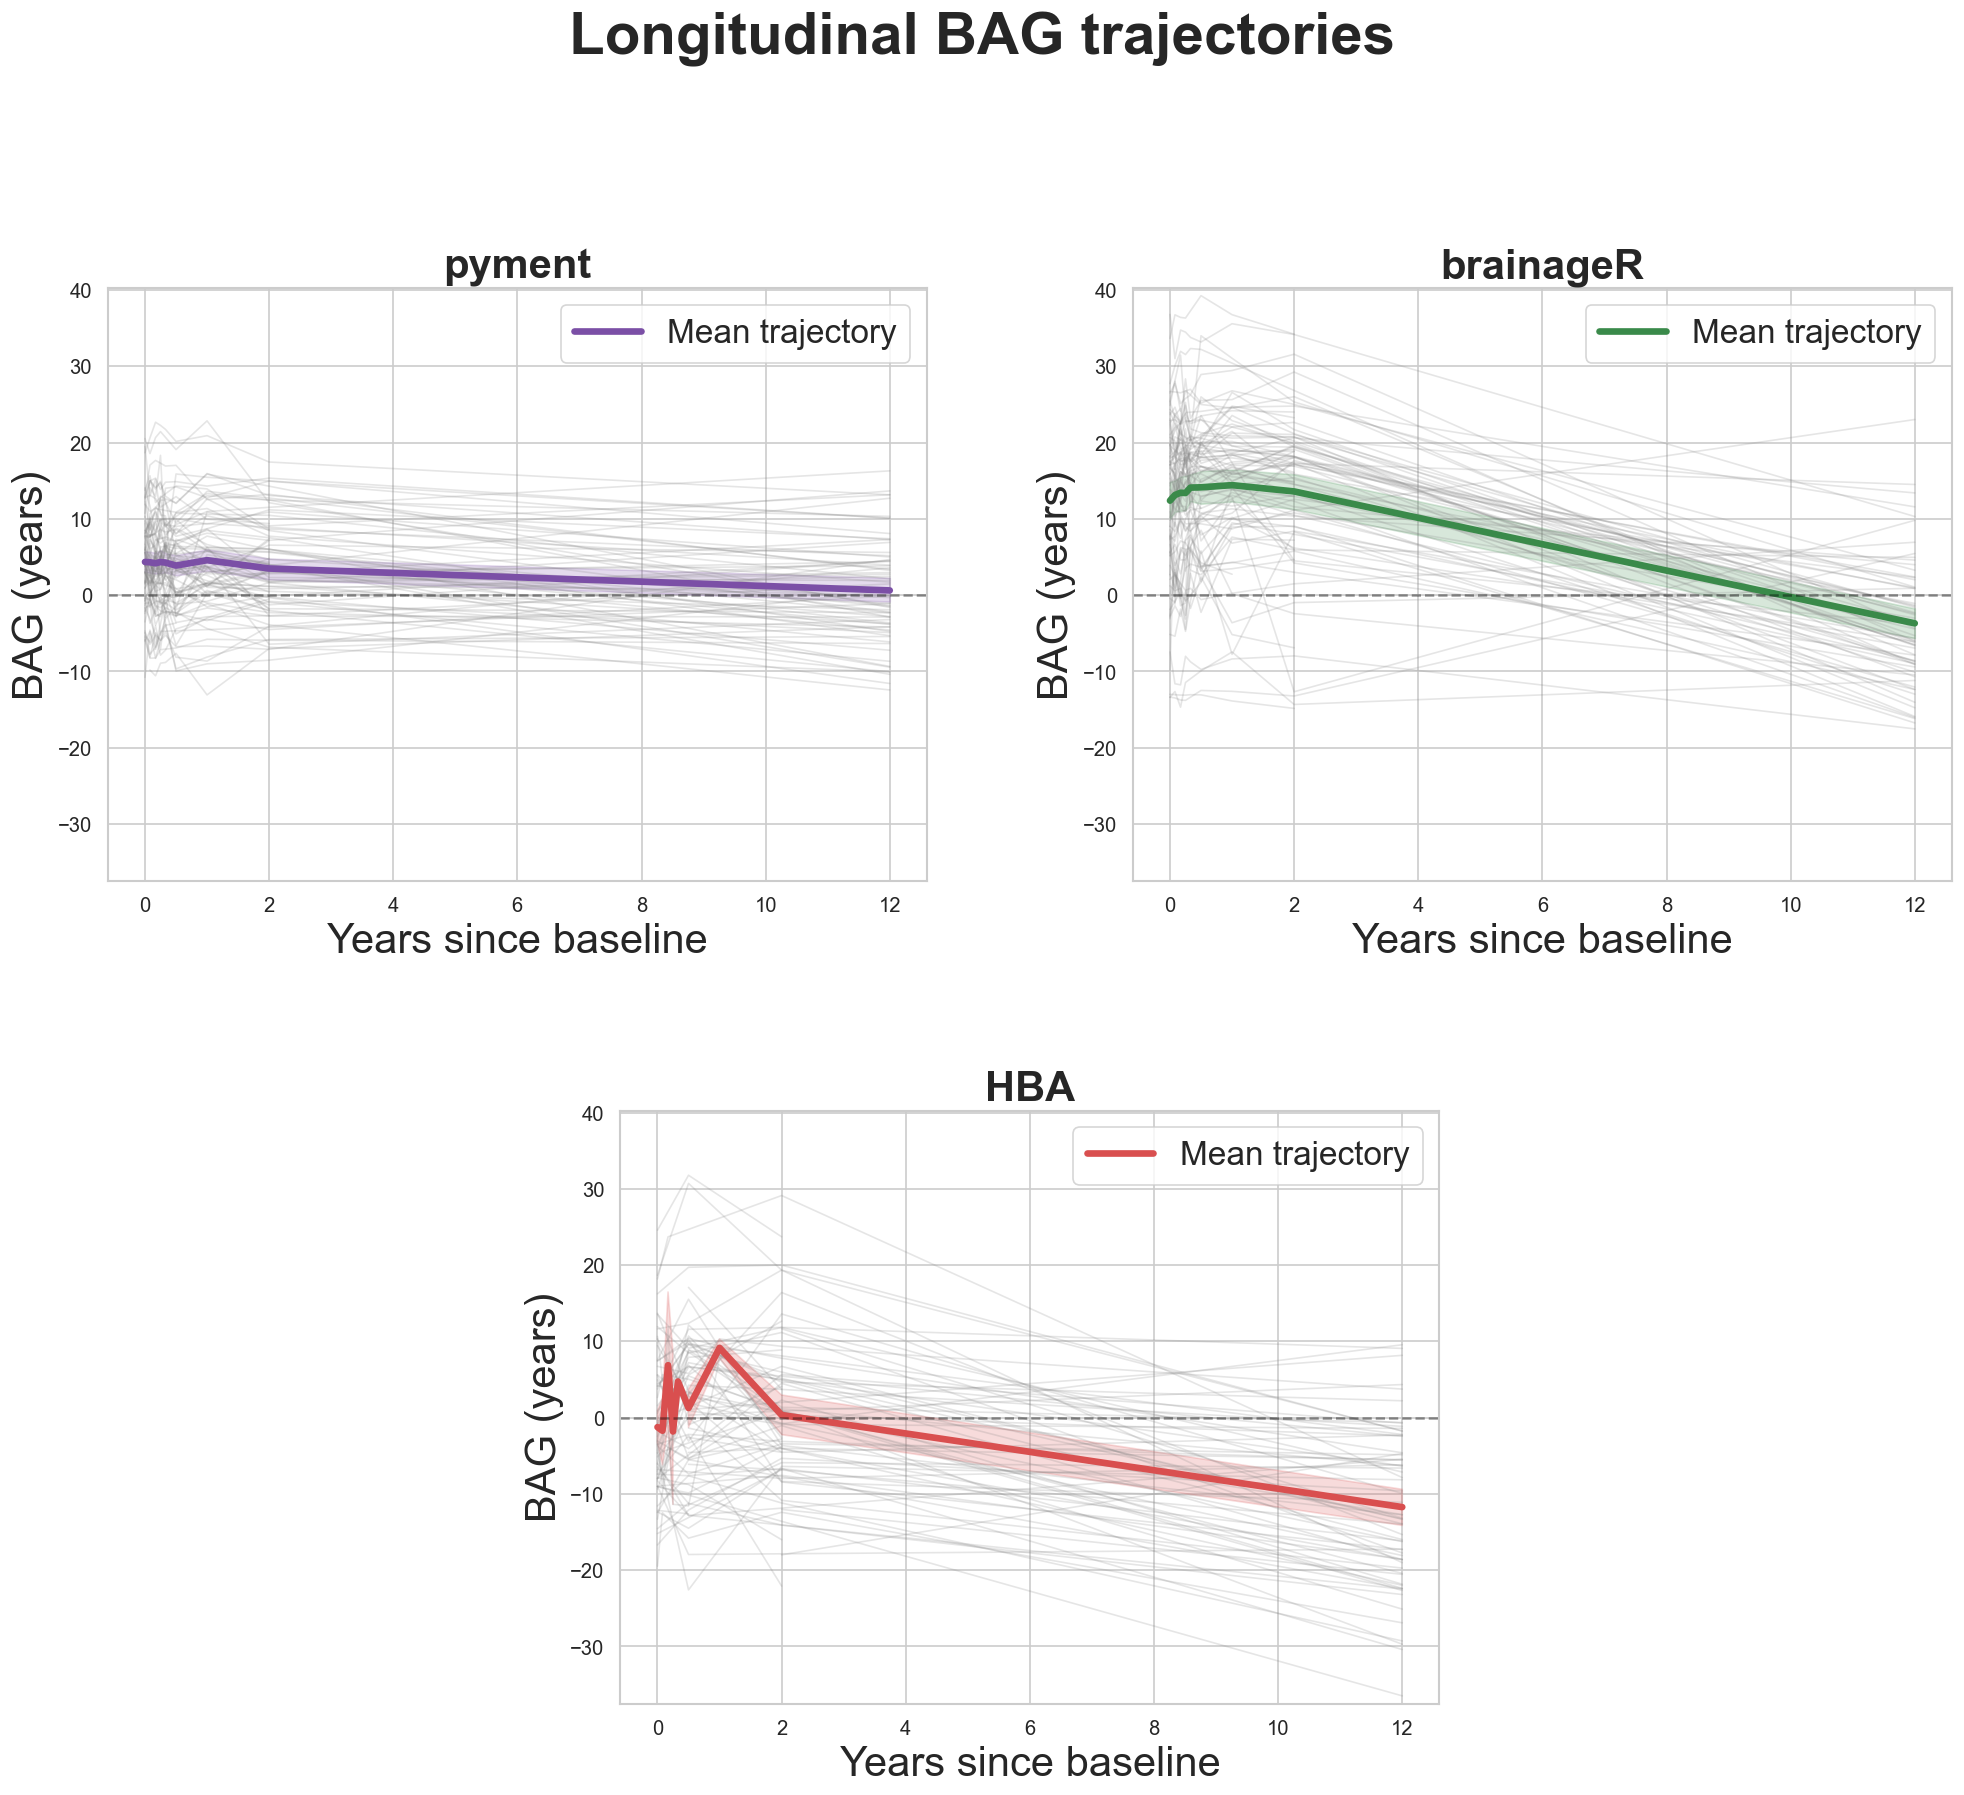

In [13]:
# Longitudinal BAG trajectories: individual subjects and group mean

fig = plt.figure(figsize=(18, 16))

# 2x4 grid allows precise centering of the bottom panel
gs   = gridspec.GridSpec(2, 4, figure=fig)
ax1  = fig.add_subplot(gs[0, 0:2])   # top left
ax2  = fig.add_subplot(gs[0, 2:4])   # top right
ax3  = fig.add_subplot(gs[1, 1:3])   # bottom center
axes = [ax1, ax2, ax3]

# Shared y-axis limits across all panels for direct comparison
y_min = min(df['BAG'].min() for df in [pyment, bar, hba]) - 1
y_max = max(df['BAG'].max() for df in [pyment, bar, hba]) + 1

for ax, df, name in zip(axes, [pyment, bar, hba], ['pyment', 'brainageR', 'HBA']):
    color = COLORS[name]

    # Individual subject trajectories (light grey for legibility)
    sns.lineplot(
        data=df, x='years_since_baseline', y='BAG',
        units='subject', estimator=None,
        ax=ax, color='gray', alpha=0.2, linewidth=1
    )

    # Group mean trajectory
    sns.lineplot(
        data=df, x='years_since_baseline', y='BAG',
        estimator='mean',
        ax=ax, color=color, linewidth=4, label='Mean trajectory'
    )

    # Reference line at BAG = 0
    ax.axhline(0, color='black', linestyle='--', alpha=0.4)

    ax.set_title(name, fontsize=25, fontweight='bold')
    ax.set_xlabel('Years since baseline', fontsize=25)
    ax.set_ylabel('BAG (years)', fontsize=25)
    ax.set_ylim(y_min, y_max)
    ax.legend(fontsize=20, loc='upper right')

fig.suptitle("Longitudinal BAG trajectories",
             fontsize=35, fontweight='bold', y=0.98)
plt.tight_layout(pad=5.0)
plt.savefig('longitudinal_bag_trajectories.png', dpi=200, bbox_inches='tight')
plt.show()

## 4.3 Linear Mixed-Effects Model: Change in Predicted Brain Age Over Time

A linear mixed-effects (LME) model is used to assess whether predicted brain
age changes systematically over the follow-up period. LME models are designed
for longitudinal data where observations within the same subject are not
independent. By including a random intercept per subject, the model accounts
for the fact that each person has their own baseline brain age level, and
estimates the population-level trajectory net of this between-subject
variability.

The fixed-effects structure is:

    predicted_age ~ years_since_baseline + age + sex + disease_duration

The slope of years_since_baseline is the primary parameter of interest: a
positive slope indicates that predicted brain age increases over time beyond
what would be expected from normal ageing (which is already captured by the
age term), consistent with progressive neurodegeneration. A slope not
significantly different from zero would suggest that the models do not detect
accelerated brain ageing over the follow-up period in this cohort.

Age, sex, and disease duration are included as fixed-effect covariates to
control for their potential confounding influence on the trajectory.

In [15]:
def run_lme_analysis(df, name):
    """
    Fit a linear mixed-effects model to assess change in predicted brain age over time.

    Model: predicted_age ~ age + sex + years_since_baseline + disease_duration
    Random intercept per subject accounts for repeated measurements.
    The slope of years_since_baseline reflects the annual rate of change in
    predicted brain age, independent of age, sex, and disease duration.

    Parameters
    ----------
    df : DataFrame
        Full longitudinal dataframe for one model.
    name : str
        Model name used for printed output.

    Returns
    -------
    MixedLMResults
        Fitted statsmodels MixedLM result object.
    """
    model_df = df.dropna(subset=[
        'predicted_age', 'age', 'sex',
        'years_since_baseline', 'subject', 'DISEASE_DURATION'
    ]).copy()

    # Random intercept per subject; random slope (commented out) can be
    # enabled with re_formula="~years_since_baseline" if convergence allows
    model = smf.mixedlm(
        "predicted_age ~ age + sex + years_since_baseline + DISEASE_DURATION",
        data=model_df,
        groups=model_df["subject"]
        # re_formula="~years_since_baseline"
    )
    result = model.fit()
    print(result.summary())

    # Extract key parameters for the time effect
    slope   = result.params['years_since_baseline']
    p_value = result.pvalues['years_since_baseline']
    intercept = result.params['Intercept']

    print(f"\n===== LME results: {name} =====")
    print(f"Intercept (at baseline):  {intercept:.3f}")
    print(f"Slope (years/year):       {slope:.3f}")
    print(f"p-value (time effect):    {p_value:.4f}")

    if p_value < 0.05:
        print(f"Conclusion: {name} shows a significant change in predicted brain age over time.")
    else:
        print(f"Conclusion: {name} shows no significant change in predicted brain age over time.")

    return result


# Run LME analysis for all three models
lme_pyment = run_lme_analysis(pyment, 'pyment')
lme_bar    = run_lme_analysis(bar,    'brainageR')
lme_hba    = run_lme_analysis(hba,    'HBA')

            Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  predicted_age
No. Observations:  729      Method:              REML         
No. Groups:        88       Scale:               8.8880       
Min. group size:   1        Log-Likelihood:      -1961.2086   
Max. group size:   9        Converged:           Yes          
Mean group size:   8.3                                        
--------------------------------------------------------------
                     Coef.  Std.Err.   z   P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept            20.457    2.318 8.824 0.000 15.914 25.001
sex[T.M]              0.350    1.018 0.344 0.731 -1.644  2.345
age                   0.576    0.058 9.879 0.000  0.462  0.690
years_since_baseline  0.081    0.066 1.227 0.220 -0.048  0.209
DISEASE_DURATION      0.149    0.158 0.943 0.346 -0.160  0.458
Group Var            19.247    1.138                          


===

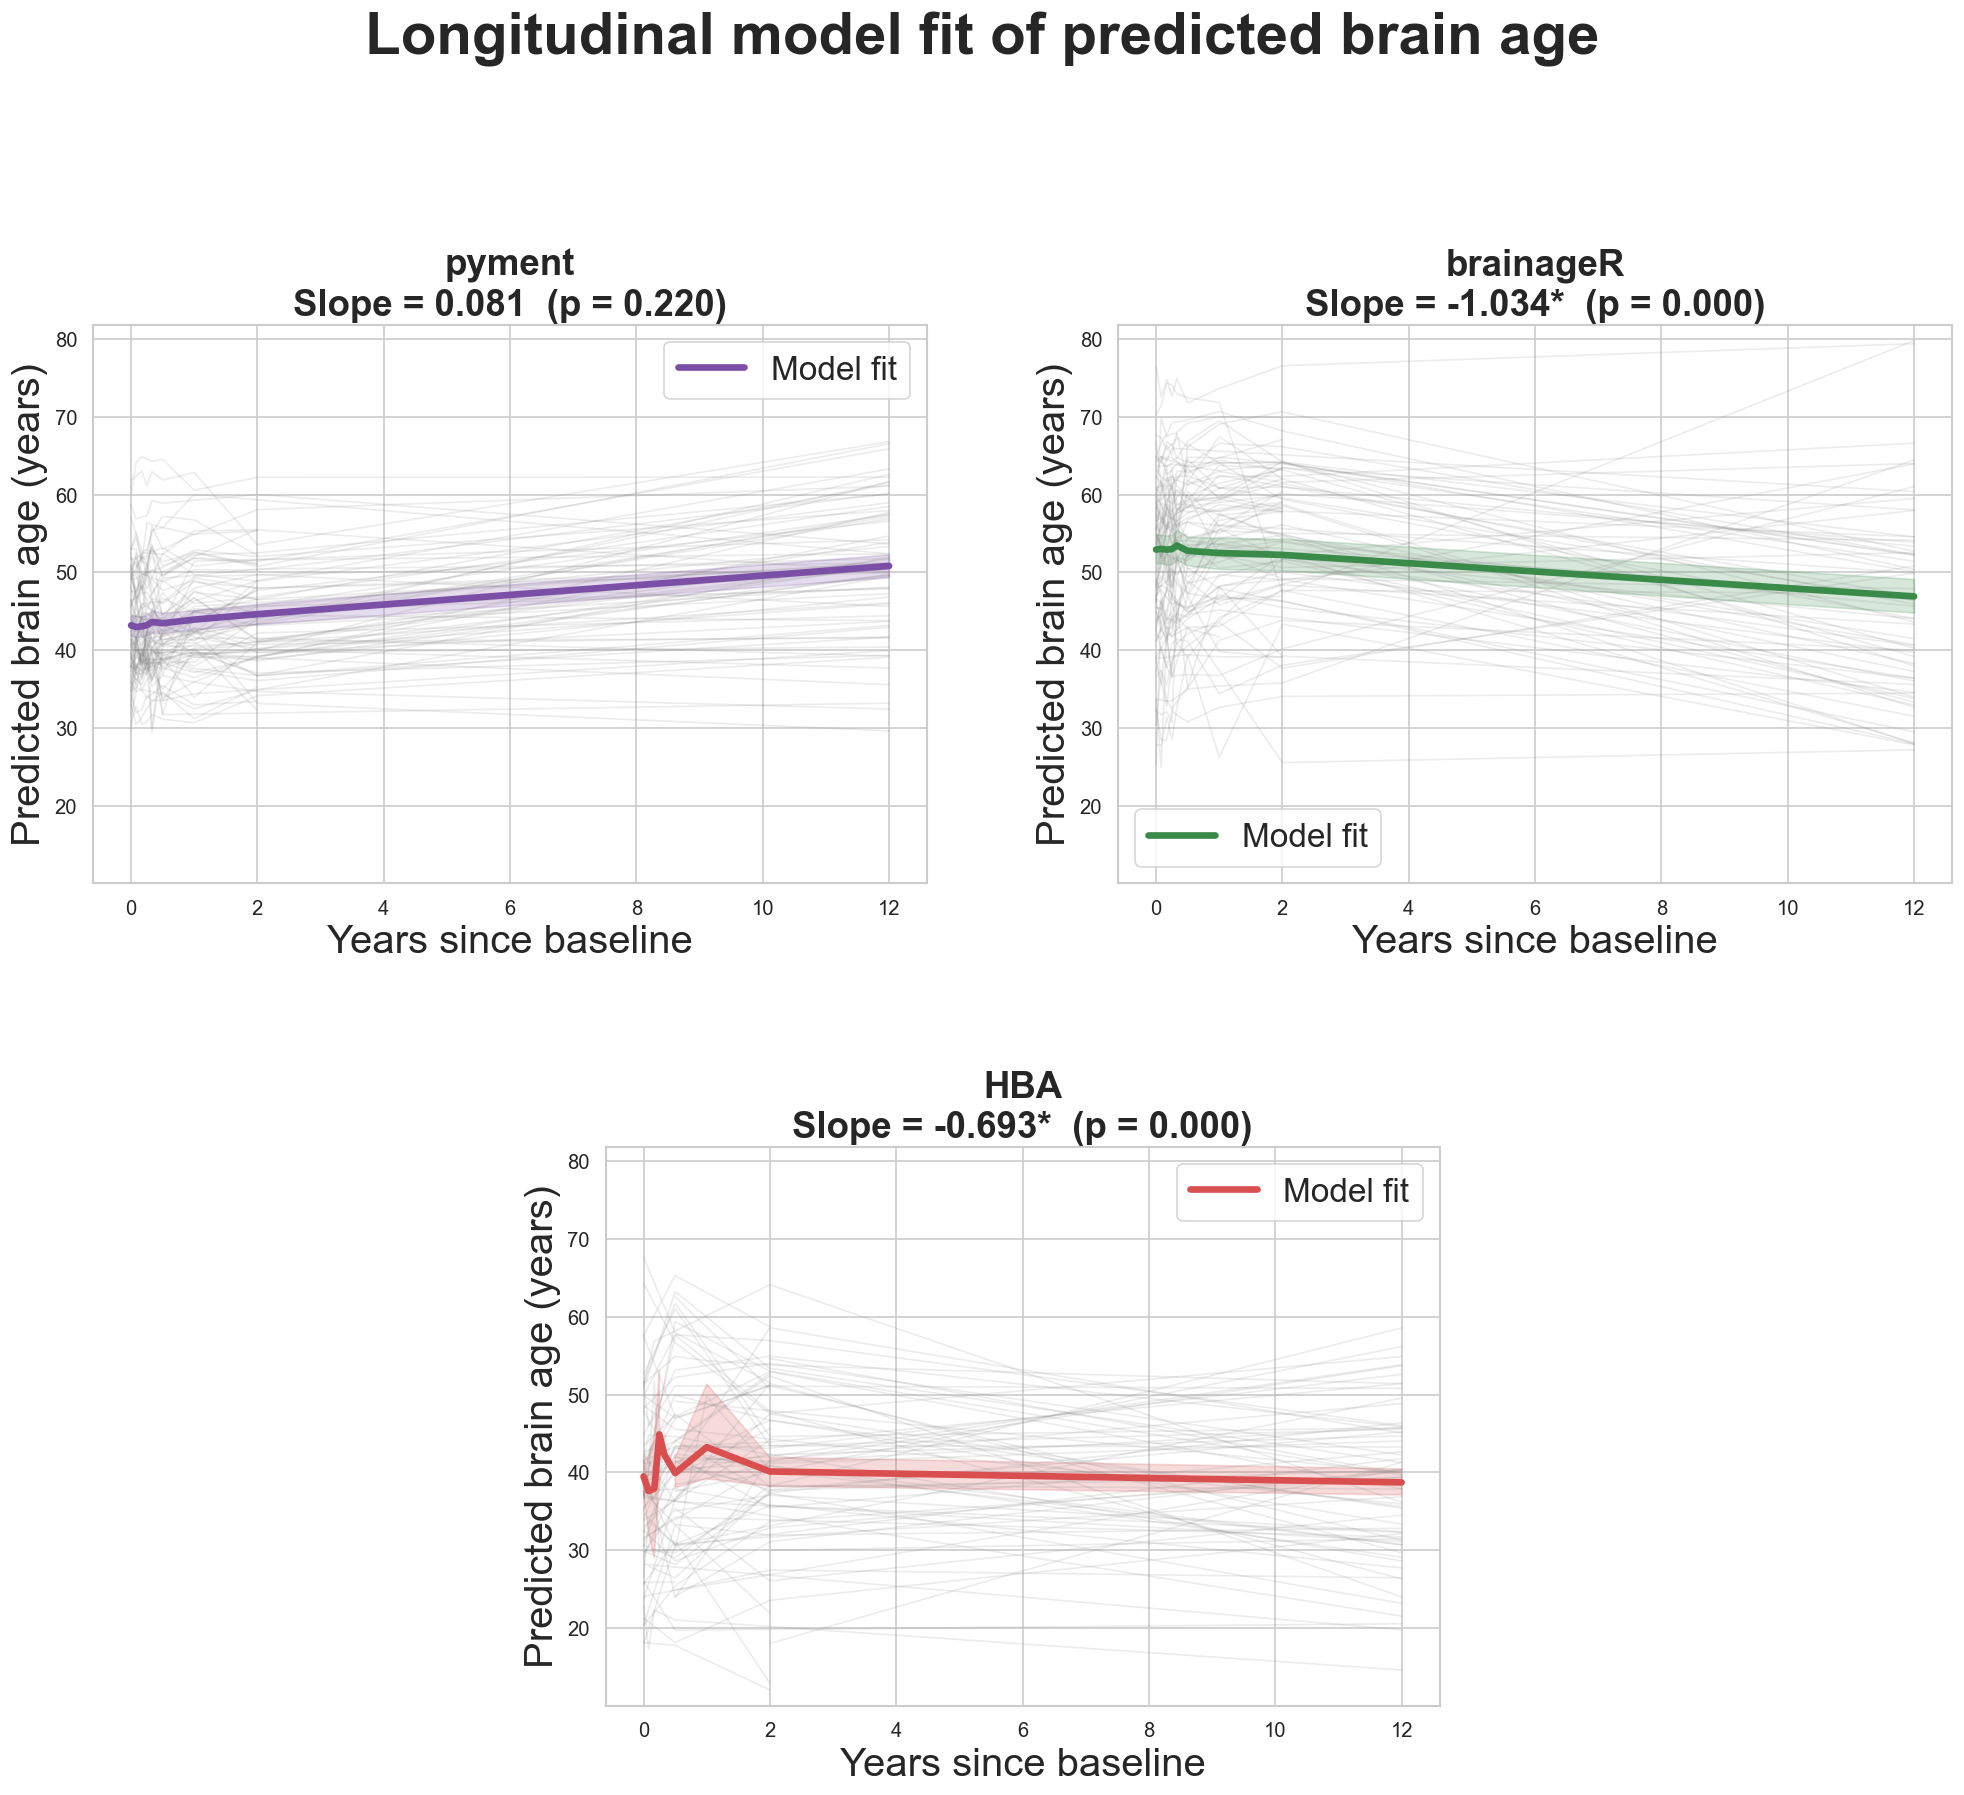

In [16]:
def plot_lme_fit(df, ax, name, color):
    """
    Fit a LME model and plot individual trajectories alongside the group-level model fit.

    Parameters
    ----------
    df : DataFrame
        Full longitudinal dataframe for one model.
    ax : matplotlib Axes
        Axes object to plot on.
    name : str
        Model name used in the panel title.
    color : str
        Line color for the model fit.

    Returns
    -------
    result : MixedLMResults
        Fitted LME result object.
    y_min, y_max : float
        Observed range of predicted age for shared y-axis scaling.
    """
    model_df = df.dropna(subset=[
        'predicted_age', 'age', 'sex',
        'years_since_baseline', 'subject', 'DISEASE_DURATION'
    ]).copy()

    model = smf.mixedlm(
        "predicted_age ~ age + sex + years_since_baseline + DISEASE_DURATION",
        data=model_df,
        groups=model_df["subject"]
        # re_formula="~years_since_baseline"
    )
    result = model.fit()

    # Store fixed-effects fitted values for group-level trajectory
    model_df["predicted_fit"] = result.fittedvalues

    slope = result.params['years_since_baseline']
    p_val = result.pvalues['years_since_baseline']

    # Individual subject trajectories (light grey)
    sns.lineplot(
        data=model_df,
        x="years_since_baseline",
        y="predicted_age",
        units="subject",
        estimator=None,
        color="gray",
        alpha=0.15,
        linewidth=1,
        ax=ax
    )

    # Group-level LME model fit
    sns.lineplot(
        data=model_df,
        x="years_since_baseline",
        y="predicted_fit",
        estimator="mean",
        color=color,
        linewidth=4,
        label="Model fit",
        ax=ax
    )

    sig = '*' if p_val < 0.05 else ''
    ax.set_title(f"{name}\nSlope = {slope:.3f}{sig}  (p = {p_val:.3f})",
                 fontsize=22, fontweight="bold")
    ax.set_xlabel("Years since baseline", fontsize=24)
    ax.set_ylabel("Predicted brain age (years)", fontsize=24)
    ax.axhline(0, linestyle="--", color="black", alpha=0.3)
    ax.legend(fontsize=20)

    return result, model_df["predicted_age"].min(), model_df["predicted_age"].max()


# 2-over-1 grid layout
fig = plt.figure(figsize=(18, 16))
gs  = gridspec.GridSpec(2, 4, figure=fig)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[1, 1:3])

res_pyment, min1, max1 = plot_lme_fit(pyment, ax1, 'pyment',    COLORS['pyment'])
res_bar,    min2, max2 = plot_lme_fit(bar,    ax2, 'brainageR', COLORS['brainageR'])
res_hba,    min3, max3 = plot_lme_fit(hba,    ax3, 'HBA',       COLORS['HBA'])

# Apply shared y-axis limits for direct comparison across panels
y_min = min(min1, min2, min3) - 2
y_max = max(max1, max2, max3) + 2
for ax in [ax1, ax2, ax3]:
    ax.set_ylim(y_min, y_max)

fig.suptitle("Longitudinal model fit of predicted brain age",
             fontsize=35, fontweight='bold', y=0.98)
plt.tight_layout(pad=5.0)
plt.savefig('lme_predicted_age_trajectories.png', dpi=200, bbox_inches='tight')
plt.show()

## 4.4 Prognostic Value of Baseline BAG

A central clinical question is whether brain age at baseline carries
information about future disease trajectory, beyond what is already known
from standard clinical assessment. Concretely: given two patients with the
same chronological age, sex, disease duration, and EDSS score today, does
the patient with the higher baseline BAG show greater disability progression
over the following 10 years?

Two complementary analyses address this question.

### BAG as a predictor of EDSS progression
OLS regression is used to test whether baseline BAG predicts disability
progression to 10-year follow-up (m120). The primary model uses delta EDSS
(edss_m120 − edss_baseline) as the outcome, directly quantifying change in
disability. A secondary model uses raw EDSS at m120 as the outcome with
baseline EDSS included as a covariate, which is mathematically equivalent
in interpretation but retains more statistical information. Convergence
of both models strengthens the reliability of any finding.

In [19]:
def predict_future_edss(df_long, model_name):
    """
    Assess whether baseline BAG predicts EDSS progression to 10-year follow-up (m120).
    Two complementary models are fitted:
    Model 1 — delta EDSS (primary):
        delta_edss ~ BAG_baseline + age + sex + disease_duration
    Model 2 — future EDSS controlling for baseline (secondary):
        edss_m120 ~ BAG_baseline + edss_baseline + age + sex + disease_duration
    If both models agree, the conclusion is robust. If they diverge, this
    warrants further discussion.

    Parameters
    ----------
    df_long : DataFrame
        Full longitudinal dataframe for one model.
    model_name : str
        Model name used for printed output.

    Returns
    -------
    tuple of (OLSResults, OLSResults, dict)
        (model1_result, model2_result, raw_results)
    """
    bl_data  = df_long[df_long['session'] == 'baseline'].copy()
    fup_data = df_long[df_long['session'] == 'm120'].copy()

    bl_data['BAG_baseline'] = bl_data['predicted_age'] - bl_data['age']

    fup_subset = (fup_data[['subject', 'edss_score']]
                  .rename(columns={'edss_score': 'edss_m120'}))

    pred_df = (bl_data
               .merge(fup_subset, on='subject', how='inner')
               .dropna(subset=['edss_m120', 'BAG_baseline',
                               'edss_score', 'age', 'sex', 'DISEASE_DURATION']))

    pred_df['delta_edss'] = pred_df['edss_m120'] - pred_df['edss_score']

    print(f"\n{'='*60}")
    print(f"{model_name}: N = {len(pred_df)} subjects with baseline and m120 data")
    print(f"Mean delta EDSS: {pred_df['delta_edss'].mean():+.2f} "
          f"± {pred_df['delta_edss'].std():.2f}")
    print(f"{'='*60}")

    # Model 1: delta EDSS (primary)
    model1 = smf.ols(
        "delta_edss ~ BAG_baseline + age + C(sex) + DISEASE_DURATION",
        data=pred_df
    ).fit()
    coef1 = model1.params['BAG_baseline']
    p1    = model1.pvalues['BAG_baseline']
    ci1   = model1.conf_int().loc['BAG_baseline'].tolist()

    print(f"\nModel 1 — delta EDSS (primary):")
    print(f"  BAG_baseline: coeff = {coef1:.3f}, p = {p1:.4f}")
    print(model1.summary().tables[1])

    # Model 2: future EDSS controlling for baseline (secondary)
    model2 = smf.ols(
        "edss_m120 ~ BAG_baseline + edss_score + age + C(sex) + DISEASE_DURATION",
        data=pred_df
    ).fit()
    coef2 = model2.params['BAG_baseline']
    p2    = model2.pvalues['BAG_baseline']
    ci2   = model2.conf_int().loc['BAG_baseline'].tolist()

    print(f"\nModel 2 — future EDSS with baseline EDSS as covariate (secondary):")
    print(f"  BAG_baseline: coeff = {coef2:.3f}, p = {p2:.4f}")
    print(model2.summary().tables[1])

    same_direction = (coef1 > 0) == (coef2 > 0)
    both_sig       = (p1 < 0.05) and (p2 < 0.05)
    print(f"\nConsistency: same direction = {same_direction}, "
          f"both significant = {both_sig}")

    raw_results = {
        'model1': {'coef': coef1, 'p': p1, 'ci': ci1},
        'model2': {'coef': coef2, 'p': p2, 'ci': ci2}
    }

    return model1, model2, raw_results


# Run predictive analysis for all three models
m1_pyment, m2_pyment, res_pyment = predict_future_edss(pyment, 'pyment')
m1_bar,    m2_bar,    res_bar    = predict_future_edss(bar,    'brainageR')
m1_hba,    m2_hba,    res_hba    = predict_future_edss(hba,    'HBA')


pyment: N = 68 subjects with baseline and m120 data
Mean delta EDSS: +0.83 ± 1.33

Model 1 — delta EDSS (primary):
  BAG_baseline: coeff = 0.077, p = 0.0137
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -1.9552      0.961     -2.035      0.046      -3.875      -0.036
C(sex)[T.M]         -0.4842      0.335     -1.446      0.153      -1.153       0.185
BAG_baseline         0.0771      0.030      2.535      0.014       0.016       0.138
age                  0.0660      0.023      2.889      0.005       0.020       0.112
DISEASE_DURATION     0.0314      0.048      0.648      0.520      -0.065       0.128

Model 2 — future EDSS with baseline EDSS as covariate (secondary):
  BAG_baseline: coeff = 0.092, p = 0.0028
                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------

In [20]:
# ── Bonferroni correction: predictive analyses (m=3 per model specification) ──

models      = ['pyment', 'brainageR', 'HBA']
all_results = [res_pyment, res_bar, res_hba]

print("Bonferroni correction: predictive analyses (m = 3 per specification)")
print("=" * 65)

for spec, label in [('model1', 'Model 1 — delta EDSS'),
                    ('model2', 'Model 2 — EDSS m120')]:
    p_vals = [r[spec]['p'] for r in all_results]
    reject, p_corrected, _, alpha_corr = multipletests(
        p_vals, alpha=0.05, method='bonferroni'
    )
    print(f"\n{label} (corrected α = {alpha_corr:.4f})")
    print("-" * 65)
    for name, r, p_corr, sig in zip(models, all_results, p_corrected, reject):
        star = '*' if sig else 'ns'
        ci   = r[spec]['ci']
        print(f"  {name}: coeff = {r[spec]['coef']:.3f}  "
              f"CI = [{ci[0]:.3f}, {ci[1]:.3f}]  "
              f"p = {r[spec]['p']:.4f}  p_corr = {p_corr:.4f}  {star}")

Bonferroni correction: predictive analyses (m = 3 per specification)

Model 1 — delta EDSS (corrected α = 0.0167)
-----------------------------------------------------------------
  pyment: coeff = 0.077  CI = [0.016, 0.138]  p = 0.0137  p_corr = 0.0412  *
  brainageR: coeff = 0.024  CI = [-0.010, 0.058]  p = 0.1664  p_corr = 0.4992  ns
  HBA: coeff = 0.013  CI = [-0.031, 0.057]  p = 0.5593  p_corr = 1.0000  ns

Model 2 — EDSS m120 (corrected α = 0.0167)
-----------------------------------------------------------------
  pyment: coeff = 0.092  CI = [0.033, 0.151]  p = 0.0028  p_corr = 0.0083  *
  brainageR: coeff = 0.023  CI = [-0.010, 0.056]  p = 0.1754  p_corr = 0.5263  ns
  HBA: coeff = 0.012  CI = [-0.032, 0.055]  p = 0.5855  p_corr = 1.0000  ns


### Incremental model fit
To assess clinical added value, two nested models are compared: a clinical
baseline model containing only established predictors (baseline EDSS, age,
sex, disease duration), and an extended model additionally including baseline
BAG. The likelihood ratio test (LRT) determines whether adding BAG
significantly improves model fit, and delta R² quantifies the unique variance
in future EDSS attributable to baseline BAG. This analysis is conducted at
both 2-year (m24) and 10-year (m120) follow-up to assess whether the
prognostic signal strengthens over longer time horizons.

In [39]:
def compare_model_fit(df_long, model_name, followup="m24"):
    """
    Assess incremental predictive value of baseline BAG over clinical predictors.

    Compares a clinical reference model (baseline EDSS, age, sex, disease duration)
    against an extended model additionally including baseline BAG. Model fit is
    evaluated using the likelihood ratio test (LRT) and delta R².

    Parameters
    ----------
    df_long : DataFrame
        Full longitudinal dataframe for one model.
    model_name : str
        Model name used in output.
    followup : str
        Session label for the follow-up timepoint (default: 'm24').

    Returns
    -------
    dict
        Model comparison metrics including R², delta R², LRT, and p-value.
    """
    bl_data  = df_long[df_long["session"] == "baseline"].copy()
    fup_data = df_long[df_long["session"] == followup].copy()

    bl_data["BAG_baseline"] = bl_data["predicted_age"] - bl_data["age"]

    outcome_col = f"edss_{followup}"
    fup_subset  = fup_data[["subject", "edss_score"]].rename(
        columns={"edss_score": outcome_col}
    )

    pred_df = bl_data.merge(fup_subset, on="subject", how="inner").dropna(
        subset=[outcome_col, "BAG_baseline", "edss_score",
                "age", "sex", "DISEASE_DURATION"]
    )

    # Clinical reference model: established predictors only
    model1 = smf.ols(
        f"{outcome_col} ~ edss_score + age + C(sex) + DISEASE_DURATION",
        data=pred_df
    ).fit()

    # Extended model: clinical predictors + baseline BAG
    model2 = smf.ols(
        f"{outcome_col} ~ BAG_baseline + edss_score + age + C(sex) + DISEASE_DURATION",
        data=pred_df
    ).fit()

    # Likelihood ratio test: does adding BAG significantly improve model fit?
    lr_stat     = -2 * (model1.llf - model2.llf)
    p_value_lrt = stats.chi2.sf(lr_stat, df=1)

    return {
        "model_name":  model_name,
        "followup":    followup,
        "n":           len(pred_df),
        "clinical_r2": round(model1.rsquared, 4),
        "extended_r2": round(model2.rsquared, 4),
        "delta_r2":    round(model2.rsquared - model1.rsquared, 4),
        "lrt":         round(lr_stat, 3),
        "p_lrt":       round(p_value_lrt, 4),
    }


# Run for m24 and m120
results_m24  = [compare_model_fit(df, name, "m24")
                for df, name in zip([pyment, bar, hba],
                                    ['pyment', 'brainageR', 'HBA'])]
results_m120 = [compare_model_fit(df, name, "m120")
                for df, name in zip([pyment, bar, hba],
                                    ['pyment', 'brainageR', 'HBA'])]

results_df = pd.DataFrame(results_m24 + results_m120)
results_df

,model_name,followup,n,clinical_r2,extended_r2,delta_r2,lrt,p_lrt
0,pyment,m24,74,0.3202,0.3570,0.0368,4.117,0.0425
1,brainageR,m24,74,0.3202,0.3440,0.0238,2.635,0.1045
2,HBA,m24,54,0.2686,0.2686,0.0000,0.001,0.9799
3,pyment,m120,68,0.2051,0.3128,0.1077,9.900,0.0017
4,brainageR,m120,65,0.2054,0.2300,0.0245,2.040,0.1532
5,HBA,m120,54,0.1632,0.1684,0.0052,0.338,0.5609


In [37]:
# ── Bonferroni correction: incremental model fit (m=3 per timepoint) ─────────

print("Bonferroni correction: incremental model fit")
print("=" * 60)

for label, results in [("2-year follow-up (m24)", results_m24),
                        ("10-year follow-up (m120)", results_m120)]:
    p_vals = [r["p_lrt"] for r in results]
    reject, p_corrected, _, alpha_corr = multipletests(
        p_vals, alpha=0.05, method='bonferroni'
    )
    print(f"\n{label} (corrected α = {alpha_corr:.4f})")
    print("-" * 60)
    for r, p_corr, sig in zip(results, p_corrected, reject):
        star = '*' if sig else 'ns'
        print(f"  {r['model_name']}: delta_R² = {r['delta_r2']:.4f}  "
              f"LRT = {r['lrt']:.3f}  p = {r['p_lrt']:.4f}  "
              f"p_corr = {p_corr:.4f}  {star}")
        

Bonferroni correction: incremental model fit

2-year follow-up (m24) (corrected α = 0.0167)
------------------------------------------------------------
  pyment: delta_R² = 0.0368  LRT = 4.117  p = 0.0425  p_corr = 0.1275  ns
  brainageR: delta_R² = 0.0238  LRT = 2.635  p = 0.1045  p_corr = 0.3135  ns
  HBA: delta_R² = 0.0000  LRT = 0.001  p = 0.9799  p_corr = 1.0000  ns

10-year follow-up (m120) (corrected α = 0.0167)
------------------------------------------------------------
  pyment: delta_R² = 0.1077  LRT = 9.900  p = 0.0017  p_corr = 0.0051  *
  brainageR: delta_R² = 0.0245  LRT = 2.040  p = 0.1532  p_corr = 0.4596  ns
  HBA: delta_R² = 0.0052  LRT = 0.338  p = 0.5609  p_corr = 1.0000  ns
